In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, roc_curve, auc
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm


In [2]:
def flux_to_class(flux, only_main=False):
    """
    Convert flux values to solar flare classes (A, B, C, M, X).
    only_main=True returns just the main letter (A/B/C/M/X).
    """
    if isinstance(flux, str):
        flux = float(flux.replace("e", "E"))
    if flux < 1e-7:
        return 'A' if only_main else 'A (<1e-7)'
    elif flux < 1e-6:
        return 'B' if only_main else 'B (1e-7–1e-6)'
    elif flux < 1e-5:
        return 'C' if only_main else 'C (1e-6–1e-5)'
    elif flux < 1e-4:
        return 'M' if only_main else 'M (1e-5–1e-4)'
    else:
        return 'X' if only_main else 'X (>1e-4)'


In [9]:
def create_simple_image_set(base_path, balance=True):
    """
    Loads images, crops, resizes to 28x28, normalizes, and flattens.
    Returns balanced dataset (equal flares and non-flares if balance=True).
    """
    meta_csv = os.path.join(base_path, 'meta_data.csv')
    df = pd.read_csv(meta_csv, parse_dates=["start", "end"], index_col="id")

    images, labels = [], []

    for row_id, row in df.iterrows():
        ar_nr, p = row_id.split("_", 1)
        img_path = os.path.join(base_path, ar_nr, p)
        if not os.path.isdir(img_path):
            continue

        for img_name in os.listdir(img_path):
            if img_name.endswith('_magnetogram.jpg'):
                im = Image.open(os.path.join(img_path, img_name)).convert('L')
                im = im.crop((44, 44, 212, 212))
                im = im.resize((256, 256), Image.Resampling.LANCZOS)
                im = np.array(im) / 255.0
                label = int(flux_to_class(row['peak_flux'], only_main=True) in ['M', 'X'])
                images.append(im)
                labels.append(label)

    X, Y = np.array(images), np.array(labels)

    if balance:
        flare_idx = np.where(Y == 1)[0]
        nonflare_idx = np.where(Y == 0)[0]
        np.random.shuffle(nonflare_idx)
        nonflare_idx = nonflare_idx[:len(flare_idx)]
        idx = np.concatenate([flare_idx, nonflare_idx])
        np.random.shuffle(idx)
        X, Y = X[idx], Y[idx]

    return X, Y

# Load datasets
base_train = "/Users/yashvisingh/Documents/sunpy/data/github_data/SDOBenchmark_full/training"
base_test = "/Users/yashvisingh/Documents/sunpy/data/github_data/SDOBenchmark_full/test"

X_train, Y_train = create_simple_image_set(base_train)
X_test, Y_test = create_simple_image_set(base_test)

print(f"Train samples: {X_train.shape}, Test samples: {X_test.shape}")


Train samples: (4050, 256, 256), Test samples: (1360, 256, 256)


In [10]:
# Add channel dimension
X_train_t = torch.tensor(X_train).unsqueeze(1).float()
Y_train_t = torch.tensor(Y_train).float().unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1).float()
Y_test_t = torch.tensor(Y_test).float().unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, Y_test_t), batch_size=32)


In [11]:
import torchvision.models as models
import torch.nn.functional as F

# Load pretrained ResNet18
resnet = models.resnet18(weights=None)  # weights=None for faster training
# Adapt for 1-channel input
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
# Change final layer to binary output
resnet.fc = nn.Linear(resnet.fc.in_features, 1)

# Move to device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = resnet.to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [12]:
epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        outputs = torch.sigmoid(outputs)  # binary output
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_losses.append(running_loss / len(train_loader.dataset))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            outputs = torch.sigmoid(outputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    val_losses.append(val_loss / len(test_loader.dataset))

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")


Epoch 1/10 - Train Loss: 0.4873 | Val Loss: 1.1119
Epoch 2/10 - Train Loss: 0.4612 | Val Loss: 0.4495
Epoch 3/10 - Train Loss: 0.4367 | Val Loss: 0.5157
Epoch 4/10 - Train Loss: 0.4305 | Val Loss: 0.4779
Epoch 5/10 - Train Loss: 0.4114 | Val Loss: 0.6960
Epoch 6/10 - Train Loss: 0.3803 | Val Loss: 0.5119
Epoch 7/10 - Train Loss: 0.3442 | Val Loss: 0.6702
Epoch 8/10 - Train Loss: 0.3049 | Val Loss: 0.7150
Epoch 9/10 - Train Loss: 0.2626 | Val Loss: 1.1923
Epoch 10/10 - Train Loss: 0.2127 | Val Loss: 0.6875


Test Accuracy: 73.82%


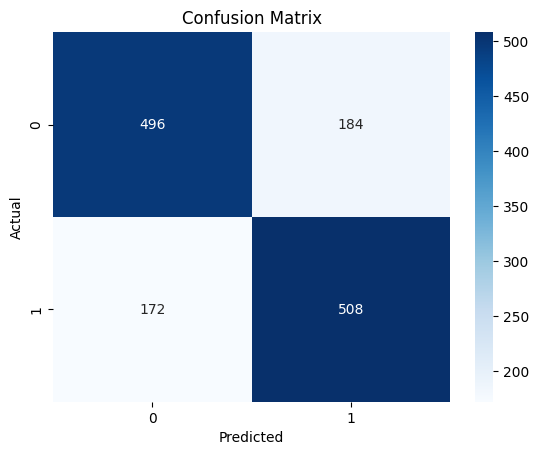

F1 Score: 0.7405247813411079


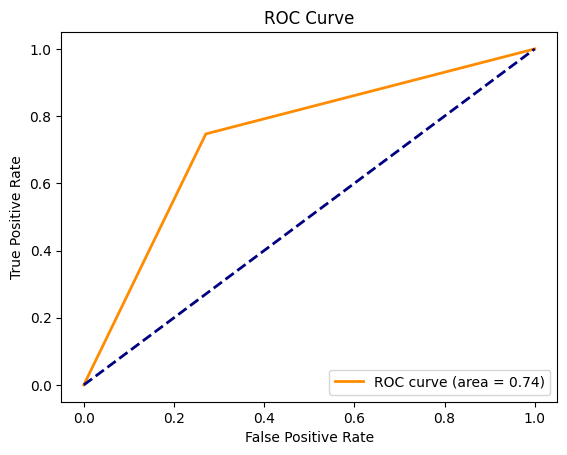

In [13]:
# Predictions
import seaborn as sns

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Accuracy
acc = (y_pred == y_true).mean()
print(f"Test Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# F1 Score
print("F1 Score:", f1_score(y_true, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
